# PLN — Aula 7: Embeddings de Palavras

Neste notebook, exploraremos representações vetoriais densas de palavras (*word embeddings*), utilizando duas abordagens:

1. **Word2Vec** — treinamento de embeddings a partir de um corpus customizado com a biblioteca Gensim.
2. **spaCy (vetores pré-treinados)** — uso de embeddings genéricos já treinados em grandes corpora de língua portuguesa.

---

## Instruções de Uso

- **Execute as células em ordem**, de cima para baixo.
- Após a primeira célula de instalação, o Colab pode solicitar que você **reinicie o runtime**. Se isso acontecer, vá em **Runtime → Reiniciar sessão** e depois execute todas as células novamente.
- Este notebook foi preparado para rodar no **Google Colab** sem configuração adicional.

# Word2Vec

Um dos modelos distribuídos mais influentes é o Word2Vec (Mikolov et al., 2013). Ele introduziu duas arquiteturas simples de rede neural para gerar embeddings: CBOW (Continuous Bag-of-Words) e Skip-Gram. Em ambas, a ideia central é aproveitar janelas de contexto em torno das palavras em um corpus de texto: o modelo aprende que palavras que ocorrem em contextos similares possuem significados similares.

No CBOW, o objetivo de treinamento é, dada uma janela de palavras de contexto, prever a palavra central; já no Skip-Gram, faz-se o inverso – dada a palavra atual (central), prever as palavras de contexto ao seu redor. Em ambos os casos, ao treinar a rede para essas predições, os pesos internos aprendidos no vetor de projeção passam a ser as representações densas das palavras.

In [1]:
# Instalação/atualização das dependências
# O Colab já possui gensim, numpy e scipy pré-instalados.
# Este comando garante que o gensim esteja na versão mais recente (>=4.4.0),
# que é compatível com o NumPy 2.x utilizado pelo Colab.
!pip install --upgrade gensim --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import nltk

from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import warnings

# Baixa o tokenizador do NLTK necessário para word_tokenize
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\SANCES_502\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Treinamento do Modelo Word2Vec

Nesta etapa, treinamos um modelo Word2Vec utilizando o corpus previamente tokenizado, armazenado na variável documentos_tokenizados. O modelo é instanciado com parâmetros específicos que influenciam tanto a qualidade quanto a performance do treinamento.

A dimensão dos vetores (vector_dim) é definida como 100, o que significa que cada palavra será representada por um vetor denso de 100 componentes. A janela de contexto (window_size) é 5, ou seja, o modelo considera até cinco palavras à esquerda e à direita da palavra-alvo para aprender relações de coocorrência. O parâmetro min_count=1 garante que todas as palavras presentes no corpus, mesmo as que aparecem uma única vez, sejam incluídas no vocabulário do modelo — uma escolha útil em corpora pequenos ou quando não se deseja perder nenhuma informação lexical. O modelo é treinado com workers=4, utilizando quatro threads em paralelo para acelerar o processo.

Por fim, o parâmetro sg=0 indica que será utilizada a arquitetura CBOW (Continuous Bag-of-Words), que aprende a prever a palavra central a partir do contexto. Se fosse configurado como sg=1, o modelo usaria o Skip-Gram, que aprende a prever o contexto a partir da palavra central. Após o treinamento, model_w2v conterá os vetores semânticos aprendidos para cada palavra no vocabulário, permitindo aplicações como cálculo de similaridade, agrupamento e visualização.

In [4]:
import pandas as pd
import numpy as np
import ast
import nltk
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

nltk.download('punkt_tab')

# ✅ Carrega seus dados
documentos = pd.read_csv("todas_as_praias_lemmatized.csv", encoding="utf-8-sig")


# 1. Pré-processamento: Tokenizar todos os documentos
documentos_tokenizados = documentos["text_stemming"].apply(ast.literal_eval).tolist()
documentos_originais   = documentos["text"].tolist()  # texto original para exibir nos resultados

# 2. Treinar o Modelo Word2Vec com todos os documentos
# Parâmetros:
vector_dim = 100 # Dimensão dos vetores
window_size = 5  # Janela de contexto
min_word_count = 2 # Contagem mínima para incluir palavra
num_workers = 4 # Threads para treinamento

model_w2v = Word2Vec(
    sentences=documentos_tokenizados,
    vector_size=vector_dim,
    window=window_size,
    min_count=min_word_count,
    workers=num_workers,
    sg=0 # Usando CBOW (padrão), 1 para Skip-gram
)

print(f"Modelo treinado com vocabulário de {len(model_w2v.wv.index_to_key)} palavras.")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\SANCES_502\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Modelo treinado com vocabulário de 2898 palavras.


In [5]:
# 3. Calcular o Vetor Médio para cada Documento

vetores_documentos = []
for doc_tokens in documentos_tokenizados:
    # Pega os vetores das palavras no documento que existem no modelo
    vetores_palavras = [model_w2v.wv[palavra] for palavra in doc_tokens if palavra in model_w2v.wv]

    if len(vetores_palavras) > 0:
        # Calcula a média dos vetores das palavras
        vetor_medio_doc = np.mean(vetores_palavras, axis=0)
        vetores_documentos.append(vetor_medio_doc)
    else:
        # Se nenhuma palavra do documento estiver no vocabulário, adiciona um vetor de zeros
        # (Isso é raro com min_count=1, mas é bom ter por segurança)
        print(f"Aviso: Documento '{' '.join(doc_tokens)}' não possui palavras no vocabulário do modelo.")
        vetores_documentos.append(np.zeros(vector_dim))

# Garantir que temos um array NumPy
vetores_documentos = np.array(vetores_documentos)

In [6]:
# 4. Calcular a Similaridade de Cosseno entre os Documentos

# cosine_similarity calcula a similaridade entre todas as combinações de vetores
matriz_similaridade = cosine_similarity(vetores_documentos)


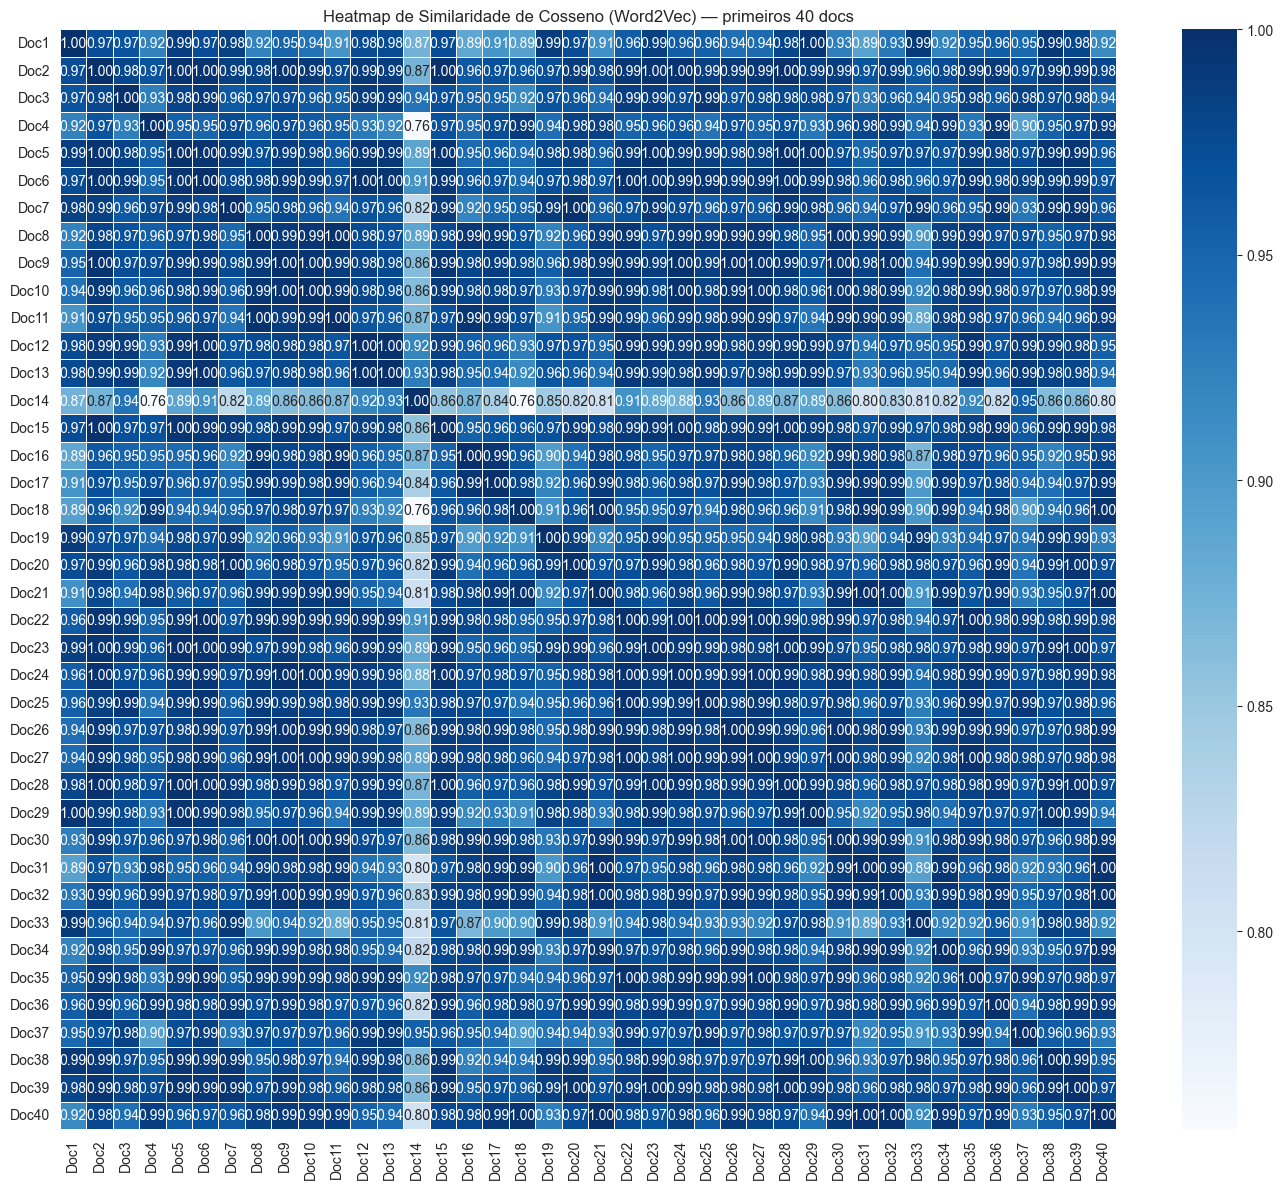

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 5. Visualizar Resultados com Heatmap

amostra_heat = 40
sim_matrix = cosine_similarity(vetores_documentos[:amostra_heat], vetores_documentos[:amostra_heat])
labels = [f"Doc{i+1}" for i in range(amostra_heat)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    pd.DataFrame(sim_matrix, index=labels, columns=labels),
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Heatmap de Similaridade de Cosseno (Word2Vec) — primeiros 40 docs")
plt.tight_layout()
plt.show()


In [18]:
import pandas as pd

def recomendar_documentos_w2v(consulta, model_w2v, documentos_originais, vetores_documentos, num_resultados=None):
    """
    Recomenda documentos com base na similaridade semântica (Word2Vec) com a consulta.

    Args:
        consulta (str): O termo ou frase de busca do usuário.
        model_w2v (gensim.models.Word2Vec): O modelo Word2Vec treinado.
        documentos_originais (list): Lista das strings dos documentos originais.
        vetores_documentos (np.ndarray): Array NumPy com os vetores médios pré-calculados
                                         para cada documento original.
        num_resultados (int, optional): Número máximo de resultados a retornar.
                                         Se None, retorna todos. Defaults to None.

    Returns:
        pd.DataFrame: DataFrame com colunas 'Documento' e 'Similaridade',
                      ordenado por similaridade decrescente. Retorna DataFrame vazio
                      se a consulta não puder ser vetorizada (nenhuma palavra conhecida).
    """
    # 1. Preprocessar (tokenizar, lowercase) a consulta
    tokens_busca = word_tokenize(consulta.lower())
    if not tokens_busca:
        print("Aviso: Consulta vazia após tokenização.")
        return pd.DataFrame({'Documento': [], 'Similaridade': []})

    # 2. Vetorizar a consulta usando o modelo Word2Vec (média dos vetores)
    vetores_palavras_busca = [model_w2v.wv[token] for token in tokens_busca if token in model_w2v.wv]

    # Verifica se alguma palavra da consulta foi encontrada no vocabulário
    if not vetores_palavras_busca:
        print(f"Aviso: Nenhuma palavra da consulta '{consulta}' encontrada no vocabulário do modelo.")
        # Retorna DataFrame vazio se a consulta não tem palavras conhecidas
        return pd.DataFrame({'Documento': [], 'Similaridade': []})

    # Calcula o vetor médio para a busca
    vetor_busca = np.mean(vetores_palavras_busca, axis=0)

    # 3. Calcular a similaridade por cosseno entre a consulta e os documentos
    # O vetor_busca precisa ser 2D (1, N_dims) para a função cosine_similarity
    similaridades = cosine_similarity(vetor_busca.reshape(1, -1), vetores_documentos)[0] # Pega a primeira (e única) linha de scores

    # 4. Obter os índices dos documentos ordenados pela similaridade (decrescente)
    indices_ranqueados = np.argsort(similaridades)[::-1]

    # 5. Criar o DataFrame de resultados com base nos índices ranqueados
    # Seleciona os documentos originais e as similaridades na ordem correta
    docs_ranqueados = [documentos_originais[i] for i in indices_ranqueados]
    scores_ranqueados = similaridades[indices_ranqueados]

    recomendacoes = pd.DataFrame({
        'Documento': docs_ranqueados,
        'Similaridade': scores_ranqueados
    })

    # 6. Limitar o número de resultados, se especificado
    if num_resultados is not None:
        recomendacoes = recomendacoes.head(num_resultados)

    return recomendacoes

# Entrada pelo usuário
termo_busca_usuario = input("Digite os termos de busca para Word2Vec: ")

# Obter as recomendações usando a função
# Você pode definir um número máximo de resultados aqui, se quiser (ex: num_resultados=5)
recomendacoes_df = recomendar_documentos_w2v(
    termo_busca_usuario,
    model_w2v,
    documentos_originais,
    vetores_documentos
    # num_resultados=5 # Descomente para limitar a 5 resultados
)

# Exibir o DataFrame resultante

if not recomendacoes_df.empty:
    print("Ok")
else:
    print("Nenhuma recomendação encontrada para o termo de busca.")

recomendacoes_df

Ok


,Documento,Similaridade
0,É um balneário muito lindo. Tem uma praia muit...,0.986879
1,Uma das melhores praia de Balneário Camboriú. ...,0.985223
2,Praia tranquila na areia e arredores e agitada...,0.983227
3,"Muito boa essa praia, muito tranquila e muito ...",0.982907
4,Muito lindo o museu e a vista da praia do Fort...,0.982662
...,...,...
6207,Praia isolada com acesso pela estrada do Araça...,0.746786
6208,Localização fácil e acessível de carro. A pano...,0.745524
6209,Muito legal unico problema é a subida de carro...,0.732782
6210,"Fomos em março, numa terça-feira , acredito qu...",0.722600


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px

In [15]:
# 1. Preparar DataFrame Inicial (se ainda não existir)
df_w2v_docs = pd.DataFrame({'Documento Original': documentos_originais})

# 2. Aplicar KMeans
# Definindo o número de clusters (pode ser ajustado/otimizado)
num_clusters = 3 # Você pode experimentar outros valores

# Aplicando o KMeans aos vetores Word2Vec
# Adicionar n_init=10 para evitar warnings e melhorar a robustez
kmeans_w2v = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

# O fit é feito diretamente nos vetores Word2Vec (que já são densos)
kmeans_w2v.fit(vetores_documentos)

# Adicionando as labels (rótulos) dos clusters ao DataFrame
df_w2v_docs['Cluster'] = kmeans_w2v.labels_

# Exibindo uma amostra dos documentos e seus clusters atribuidos
print(f"\nAmostra de Documentos e Clusters (KMeans com {num_clusters} clusters):")
df_w2v_docs[['Documento Original', 'Cluster']]



Amostra de Documentos e Clusters (KMeans com 3 clusters):


,Documento Original,Cluster
0,"Cidade tranquila, com boas praias, restaurante...",1
1,"Praia suja , mal cuidada , lixo espalhado pela...",1
2,Lugar aconchegante porém com preço de consumo ...,2
3,"Praia muito legal para ir com a família, mar c...",0
4,"Eu frequento a cidade de Penha desde 2002, é t...",1
...,...,...
6207,"A Prainha tem de tudo, barsinhos, mar especial...",2
6208,"Se quer praia com ondas fortes e agito, vá par...",0
6209,Uma pequena praia que pertence á São Francisco...,2
6210,"Prainha como é conhecida , é palco de grandes ...",0


In [16]:
# 3. Redução de Dimensionalidade com PCA para Visualização
# PCA para reduzir para 3 componentes para visualização 3D
pca_w2v = PCA(n_components=3)

# Aplicando PCA aos vetores Word2Vec (não precisa de .toarray())
caracteristicas_reduzidas_w2v = pca_w2v.fit_transform(vetores_documentos)

# 4. Preparar DataFrame para Plotagem
# Criando um DataFrame que inclui as 3 componentes PCA, Cluster e Documento
pca_w2v_df = pd.DataFrame(
    caracteristicas_reduzidas_w2v,
    columns=['Componente PCA 1', 'Componente PCA 2', 'Componente PCA 3']
)
# Adiciona as informações de cluster e documento ao DataFrame do PCA
pca_w2v_df['Cluster'] = df_w2v_docs['Cluster']
pca_w2v_df['Documento Original'] = df_w2v_docs['Documento Original']

# Convertendo os rótulos dos clusters para string para cores categóricas no Plotly
pca_w2v_df['Cluster'] = pca_w2v_df['Cluster'].astype(str)

# 5. Criar Gráfico 3D Interativo com Plotly Express
fig_w2v = px.scatter_3d(
    pca_w2v_df,
    x='Componente PCA 1',
    y='Componente PCA 2',
    z='Componente PCA 3',        # Mapeando a terceira componente para o eixo Z
    color='Cluster',             # Colorindo os pontos pelo cluster atribuído
    title='Clusters de Documentos (Word2Vec + PCA 3D)', # Título atualizado
    labels={                     # Rótulos dos eixos
        'Componente PCA 1': 'Componente PCA 1',
        'Componente PCA 2': 'Componente PCA 2',
        'Componente PCA 3': 'Componente PCA 3'
    },
    width=900,                   # Largura/Altura do gráfico (ajustável)
    height=700,
    hover_data={                 # Dados a exibir ao passar o mouse sobre um ponto
        'Componente PCA 1': ':.2f', # Formata PCA para 2 casas decimais no hover
        'Componente PCA 2': ':.2f',
        'Componente PCA 3': ':.2f',
        'Cluster': True, # Mostra o número do cluster
        'Documento Original': True # Mostra o texto do documento original
    }
    # Alternativa para hover_data: hover_data=['Documento Original', 'Cluster']
)

# Opcional: Ajustar a aparência dos marcadores
# fig_w2v.update_traces(marker=dict(size=5, opacity=0.8))

# Exibir o gráfico interativo
fig_w2v.show()

# Utilizando vetores pré-treinados com spaCy

Neste exemplo, utilizamos a biblioteca spaCy com o modelo pré-treinado pt_core_news_lg, que contém embeddings de palavras em português.

Especificamente, carrega-se o modelo pt_core_news_lg, que é um modelo pré-treinado para o português disponibilizado pelo próprio time do spaCy. A sigla \"lg\" indica que se trata da versão large, ou seja, um modelo que inclui vetores pré-treinados (word embeddings) de alta dimensão – tipicamente com 300 dimensões, treinados sobre grandes corpora em português.

Esses embeddings foram obtidos por meio de técnicas como Word2Vec, GloVe ou similares, treinadas em textos extensos como Wikipedia, notícias e dados da web em português. Eles permitem que cada palavra seja representada por um vetor denso, em que a proximidade no espaço vetorial corresponde a similaridade semântica.

Assim, palavras como “felino” e “gato”, por exemplo, terão vetores muito próximos entre si, enquanto “gato” e “sofá” tenderão a estar mais distantes, refletindo a diferença de significado.

**O Word2Vec gera embeddings a partir de um corpus customizado, permitindo aprender representações específicas ao domínio dos dados, enquanto os modelos pré-treinados do spaCy fornecem embeddings genéricos já treinados em grandes corpora de língua portuguesa, prontos para uso imediato sem necessidade de reprocessamento.**

In [17]:
# Instala o modelo pré-treinado de português do spaCy (versão large, com vetores)
import spacy
!python -m spacy download pt_core_news_lg --quiet

^C


In [ ]:
# Carregar modelo em português
nlp = spacy.load('pt_core_news_lg')

doc = nlp("O gato está dormindo no sofá.")
# Extrair vetores das palavras \"gato\" e \"sofá\"
gato_vec = doc[1].vector  # token 1 é \"gato\"
sofa_vec = doc[-2].vector  # token -2 é \"sofá\"
print("Dimensão do vetor em spaCy:", len(gato_vec))
print("Similaridade spaCy entre 'gato' e 'sofá':", doc[1].similarity(doc[-2]))

# Outro exemplo de similaridade semântica
palavra1 = nlp("felino")[0]
palavra2 = nlp("gato")[0]
print("Similaridade entre 'felino' e 'gato':", palavra1.similarity(palavra2))


Dimensão do vetor em spaCy: 300
Similaridade spaCy entre 'gato' e 'sofá': 0.40287303924560547
Similaridade entre 'felino' e 'gato': 0.6963788866996765
